# 7. Modelo base: regresión logística

El capítulo 6 dejó montada la maquinaria del experimento y, al final, la usó una vez para obtener una primera cifra: una regresión logística regularizada alcanza un AUC-ROC de 0.663 en validación cruzada agrupada por paciente. Ese número respondió a la pregunta de si el pipeline funciona, pero no a la pregunta de qué hace el modelo.

Este capítulo responde la segunda. Un modelo base no es un trámite previo al modelado serio: es el patrón de medida con el que se juzgarán las ciento doce combinaciones del capítulo 8, y un patrón de medida que no se entiende no sirve para medir. Si un ensamble de árboles supera a esta logística por tres milésimas de AUC, la decisión de adoptarlo depende de saber exactamente qué está capturando la logística y qué le queda fuera.

El capítulo desarrolla cuatro cosas que la sección 6.4 no hizo:

1. **Qué aprendió.** Los coeficientes y sus razones de momios, la selección de variables que induce la penalización L1, y el contraste entre ese ordenamiento y el que el capítulo 4 obtuvo con estadísticos univariados. Es la primera oportunidad de comprobar si el análisis exploratorio anticipó bien lo que un modelo multivariado encuentra.
2. **Cómo se equivoca.** Matriz de confusión en umbrales alternativos, curvas ROC y precisión-recall, y el perfil de precisión y cobertura según la fracción de altas que un hospital pudiera priorizar.
3. **Si sus probabilidades significan algo.** El diagnóstico de calibración que la sección 6.4.2 anunció y dejó pendiente, con una corrección cruzada que cuantifica cuánto se recupera.
4. **A quién se equivoca.** Las tasas de error por atributo protegido, contrastadas con las tasas base que midió la sección 4.8.

Tres reglas gobiernan el capítulo, heredadas de los anteriores. Solo se usa el conjunto de entrenamiento; la validación es agrupada por paciente; y toda cifra citada en el texto proviene de una celda ejecutada.

In [1]:
from config import *

import experimento as ex
from sklearn.model_selection import StratifiedGroupKFold

try:
    from myst_nb import glue as _glue
except ImportError:  # el notebook sigue siendo ejecutable fuera de Jupyter Book
    def _glue(clave, valor, display=False):
        return None


def anotar(clave, valor):
    """Publica un valor para poder citarlo en el texto del capítulo.

    Las celdas de texto lo recuperan con el rol ``{glue:text}``. Atar las
    cifras de la narración al código evita que la prosa afirme los
    resultados de una versión anterior del análisis.
    """
    _glue(clave, str(valor), display=False)
    return valor


roles = roles_variables()
OBJETIVO = roles["objetivo"]
IDENTIFICADOR = roles["identificador"]
PREDICTORES = (roles["numericas"] + roles["ordinales"]
               + roles["binarias"] + roles["categoricas"])

train = leer_tabla("diabetes_train")
X = train[PREDICTORES]
y = train[OBJETIVO]
grupos = train[IDENTIFICADOR]

PREVALENCIA = y.mean()

print(f"Entrenamiento : {len(X):,} encuentros de {grupos.nunique():,} pacientes")
print(f"Predictores   : {len(PREDICTORES)}")
print(f"Clase positiva: {PREVALENCIA:.2%}")

anotar("c7_encuentros", f"{len(X):,}")
anotar("c7_pacientes", f"{grupos.nunique():,}")
anotar("c7_prevalencia", f"{100 * PREVALENCIA:.2f}")

Entrenamiento : 79,473 encuentros de 56,036 pacientes
Predictores   : 38
Clase positiva: 11.39%


'11.39'

## 7.1. Especificación del modelo base

Todo el capítulo trabaja sobre los {glue:text}`c7_encuentros` encuentros de {glue:text}`c7_pacientes` pacientes del conjunto de entrenamiento, con una prevalencia de readmisión temprana del {glue:text}`c7_prevalencia` %.

### 7.1.1. Por qué una logística y no otra cosa

La elección del modelo base no es arbitraria ni es la más simple posible. Un clasificador constante o un azar estratificado serían más simples, y de hecho aparecen más abajo como referencias, pero no sirven de patrón de medida: no aprenden nada, y superarlos no dice nada de un modelo.

La regresión logística ocupa una posición particular. Es el modelo lineal generalizado canónico para un desenlace binario, de modo que su forma funcional es exactamente la hipótesis que el capítulo 4 puso a prueba cuando midió si las relaciones eran lineales en el logit. Sus coeficientes se leen como razones de momios, que es el lenguaje en el que la literatura clínica reporta factores de riesgo. Su costo computacional es de dos a tres órdenes de magnitud menor que el de un ensamble. Y con penalización L1 hace selección de variables por sí sola, lo que la convierte además en un diagnóstico de cuántas de las columnas codificadas aportan algo.

Esa combinación fija el criterio de las comparaciones posteriores: cualquier modelo más complejo debe justificar su complejidad frente a un competidor que es interpretable, barato y cuya forma funcional es la que el análisis exploratorio consideró plausible.

### 7.1.2. La configuración y por qué se fija aquí

La sección 6.4 buscó los hiperparámetros con Grid Search exhaustivo dentro de una validación anidada, y los cinco folds externos eligieron **la misma configuración**: `C = 0.1` con penalización L1. Esa unanimidad es informativa. Significa que la superficie de validación tiene un máximo claro y que la selección no depende del ruido de la partición, de modo que repetir la búsqueda aquí costaría minutos de cómputo para llegar al mismo sitio.

El capítulo la toma entonces como dada y dedica el presupuesto a entender el modelo resultante. Para que la decisión sea auditable y no un acto de fe, la sección siguiente reconstruye la superficie de validación completa sobre una submuestra de pacientes, y muestra tanto el máximo como su entorno.

In [2]:
# Configuración heredada de la búsqueda del capítulo 6, declarada de forma
# explícita para que el capítulo sea reproducible por sí solo.
CONFIGURACION = {"modelo__C": 0.1, "modelo__penalty": "l1"}
BALANCEO = "class_weight"

pipeline_base = ex.construir_pipeline("logistica", BALANCEO, roles,
                                      semilla=RANDOM_STATE)
pipeline_base.set_params(**CONFIGURACION)

estimador = pipeline_base.named_steps["modelo"]
ficha = pd.DataFrame([
    ("Familia", "Regresión logística (modelo lineal generalizado, enlace logit)"),
    ("Regularización", f"L1 con C = {CONFIGURACION['modelo__C']}"),
    ("Solver", estimador.get_params()["solver"]),
    ("Tratamiento del desbalance", 'class_weight="balanced"'),
    ("Escalado de las numéricas", "RobustScaler (mediana e IQR)"),
    ("Codificación de las categóricas", "One-hot con agrupamiento al 1 %"),
    ("Validación", "StratifiedGroupKFold, 5 folds, agrupada por paciente"),
    ("Métrica principal", "AUC-PR (precisión media)"),
], columns=["Elemento", "Elección"])

tabla(ficha, filas=10, indice=False)

### 7.1.3. La superficie de validación

La búsqueda se repite sobre una submuestra del 40 % de los **pacientes** del conjunto de entrenamiento, con validación interna de tres folds agrupada. Submuestrear por paciente y no por fila mantiene la integridad de los grupos, que es la misma precaución que el capítulo 6 adoptó para la estrategia de multi-fidelidad. El objetivo aquí no es seleccionar (eso ya ocurrió), sino ver la forma de la superficie: si el máximo es agudo, la elección del hiperparámetro es una decisión delicada; si es plano, cualquier valor del entorno sirve y el modelo es robusto a esa decisión.

Submuestra: 32,057 encuentros de 22,414 pacientes
Configuraciones evaluadas: 12


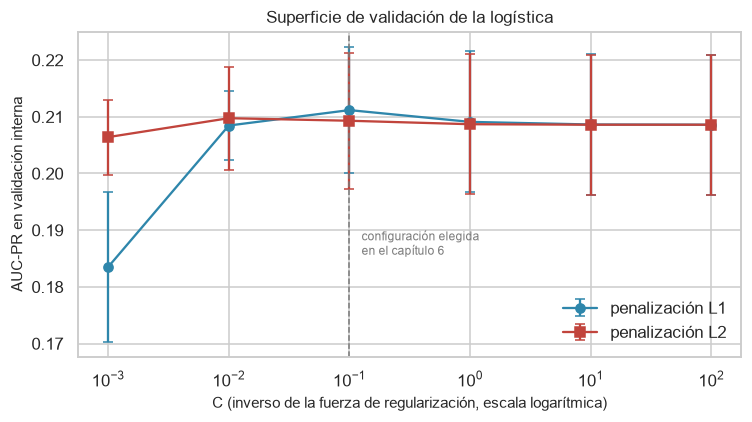

penalización,l1,l2
C,,
0.001,0.1835,0.2064
0.010,0.2084,0.2097
0.100,0.2112,0.2093
1.000,0.2091,0.2087
10.000,0.2086,0.2086
100.000,0.2086,0.2086


In [3]:
from sklearn.model_selection import cross_val_score

# Submuestra por paciente: la unidad de muestreo es el grupo, no la fila.
aleatorio = np.random.default_rng(RANDOM_STATE)
pacientes = grupos.drop_duplicates().to_numpy()
elegidos = aleatorio.choice(pacientes, size=int(0.4 * len(pacientes)),
                            replace=False)
mascara = grupos.isin(elegidos).to_numpy()
X_sub, y_sub, g_sub = X[mascara], y[mascara], grupos[mascara]

interno = StratifiedGroupKFold(n_splits=3, shuffle=True,
                               random_state=RANDOM_STATE)
rejilla = ex.rejilla_hiperparametros("logistica")

filas = []
for penalizacion in rejilla["modelo__penalty"]:
    for c in rejilla["modelo__C"]:
        candidato = ex.construir_pipeline("logistica", BALANCEO, roles,
                                          semilla=RANDOM_STATE)
        candidato.set_params(modelo__C=c, modelo__penalty=penalizacion)
        puntajes = cross_val_score(candidato, X_sub, y_sub, groups=g_sub,
                                   cv=interno, scoring="average_precision",
                                   n_jobs=1)
        filas.append({"penalización": penalizacion, "C": c,
                      "AUC-PR": np.mean(puntajes),
                      "desviación": np.std(puntajes, ddof=1)})

superficie = pd.DataFrame(filas)
print(f"Submuestra: {len(X_sub):,} encuentros de {g_sub.nunique():,} pacientes")
print(f"Configuraciones evaluadas: {len(superficie)}")

fig, eje = plt.subplots(figsize=(7, 4))
for penalizacion, marca in zip(["l1", "l2"], ["o", "s"]):
    parte = superficie[superficie["penalización"] == penalizacion]
    eje.errorbar(parte["C"], parte["AUC-PR"], yerr=parte["desviación"],
                 marker=marca, capsize=3, label=f"penalización {penalizacion.upper()}",
                 color=PALETA[0] if penalizacion == "l1" else PALETA[1])
eje.axvline(CONFIGURACION["modelo__C"], color=GRIS, linestyle="--", linewidth=1)
eje.annotate("configuración elegida\nen el capítulo 6",
             xy=(CONFIGURACION["modelo__C"], superficie["AUC-PR"].min()),
             xytext=(8, 8), textcoords="offset points", fontsize=8, color=GRIS)
eje.set_xscale("log")
eje.set_xlabel("C (inverso de la fuerza de regularización, escala logarítmica)")
eje.set_ylabel("AUC-PR en validación interna")
eje.set_title("Superficie de validación de la logística")
eje.legend()
plt.tight_layout()
plt.show()

mejor = superficie.loc[superficie["AUC-PR"].idxmax()]
l1 = superficie[superficie["penalización"] == "l1"].set_index("C")["AUC-PR"]
l2 = superficie[superficie["penalización"] == "l2"].set_index("C")["AUC-PR"]
meseta = l1[l1.index >= 0.01]

anotar("c7_mejor_c", f"{mejor['C']:g}")
anotar("c7_mejor_pen", mejor["penalización"].upper())
anotar("c7_meseta", f"{1000 * (meseta.max() - meseta.min()):.1f}")
anotar("c7_caida_l1", f"{1000 * (meseta.max() - l1.min()):.0f}")
anotar("c7_caida_l2", f"{1000 * (l2.max() - l2.min()):.0f}")
anotar("c7_sub_pacientes", f"{g_sub.nunique():,}")
anotar("c7_sub_encuentros", f"{len(X_sub):,}")
superficie.pivot(index="C", columns="penalización", values="AUC-PR").round(4)

El máximo de la submuestra, {glue:text}`c7_sub_encuentros` encuentros de {glue:text}`c7_sub_pacientes` pacientes, se alcanza en `C` = {glue:text}`c7_mejor_c` con penalización {glue:text}`c7_mejor_pen`: coincide con lo que la validación anidada del capítulo 6 eligió sobre el conjunto completo, lo que valida tomar esa configuración como dada.

La forma de la curva es más informativa que su máximo, y tiene dos regiones. De `C` = 0.01 en adelante hay una **meseta**: los cinco valores restantes de L1 se reparten en un intervalo de {glue:text}`c7_meseta` milésimas de AUC-PR, por debajo de la desviación entre folds, y las dos penalizaciones se vuelven indistinguibles. Por debajo de ese punto la regularización empieza a costar: en `C` = 0.001 la L1 pierde {glue:text}`c7_caida_l1` milésimas, mientras la L2 solo pierde {glue:text}`c7_caida_l2`. La asimetría es exactamente la que predice la teoría, porque la L1 lleva coeficientes a cero de forma exacta y con penalización suficiente vacía el modelo, mientras la L2 los encoge sin eliminarlos.

De ahí salen dos consecuencias. La primera es tranquilizadora: dentro de la meseta el desempeño del modelo base no depende de haber acertado con el hiperparámetro. La segunda es una advertencia para el capítulo 9, donde cuatro optimizadores competirán por encontrar el óptimo de espacios como este. Si la región relevante del espacio es una meseta, los cuatro llegarán a desempeños equivalentes y la comparación informativa entre ellos será por costo, no por calidad de la solución; la excepción son las zonas de colapso, y lo que distinguirá a un buen optimizador es sobre todo no quedarse atrapado en ellas.

## 7.2. Desempeño fuera de muestra

El ajuste se repite en los cinco folds externos. De cada uno se guardan tres cosas: las métricas en su partición de validación, las probabilidades predichas para esas filas, y los coeficientes del modelo ajustado. Las probabilidades de los cinco folds, concatenadas, forman una predicción fuera de muestra para cada encuentro del conjunto de entrenamiento, que es la base de todo el análisis posterior de umbrales, calibración y errores. Los coeficientes de los cinco folds permiten juzgar la estabilidad de lo que el modelo aprende.

In [4]:
import time

externo = StratifiedGroupKFold(n_splits=5, shuffle=True,
                               random_state=RANDOM_STATE)

probabilidades = np.zeros(len(y))
fold_de_fila = np.zeros(len(y), dtype=int)
metricas_por_fold, coeficientes_por_fold = [], []
nombres_columnas = None
inicio = time.perf_counter()

for i, (idx_train, idx_val) in enumerate(externo.split(X, y, groups=grupos), 1):
    ajustado = ex.construir_pipeline("logistica", BALANCEO, roles,
                                     semilla=RANDOM_STATE)
    ajustado.set_params(**CONFIGURACION)
    ajustado.fit(X.iloc[idx_train], y.iloc[idx_train])

    probas = ajustado.predict_proba(X.iloc[idx_val])[:, 1]
    probabilidades[idx_val] = probas
    fold_de_fila[idx_val] = i

    metricas_por_fold.append(ex.calcular_metricas(y.iloc[idx_val], probas))
    nombres_columnas = ex.nombres_variables(
        ajustado.named_steps["preprocesamiento"])
    coeficientes_por_fold.append(ajustado.named_steps["modelo"].coef_[0])

segundos = time.perf_counter() - inicio
coeficientes = pd.DataFrame(coeficientes_por_fold, columns=nombres_columnas,
                            index=[f"fold {i}" for i in range(1, 6)])

desempeno = pd.DataFrame({
    "media": [np.mean([f[m] for f in metricas_por_fold]) for m in ex.METRICAS],
    "desviación estándar": [np.std([f[m] for f in metricas_por_fold], ddof=1)
                            for m in ex.METRICAS],
}, index=ex.METRICAS).round(4)

print(f"Cinco ajustes completados en {segundos:.1f} s "
      f"({segundos / 5:.1f} s por fold)")
print(f"Columnas de la matriz de diseño: {len(nombres_columnas)}")

guardar_resultado(desempeno, "modelo_base_desempeno")
anotar("c7_auc_roc", f"{desempeno.loc['auc_roc', 'media']:.4f}")
anotar("c7_auc_roc_sd", f"{desempeno.loc['auc_roc', 'desviación estándar']:.4f}")
anotar("c7_auc_pr", f"{desempeno.loc['auc_pr', 'media']:.4f}")
anotar("c7_recall", f"{100 * desempeno.loc['recall', 'media']:.1f}")
anotar("c7_precision", f"{100 * desempeno.loc['precision', 'media']:.1f}")
anotar("c7_brier", f"{desempeno.loc['brier', 'media']:.4f}")
anotar("c7_columnas", len(nombres_columnas))
anotar("c7_segundos", f"{segundos:.0f}")
desempeno

Cinco ajustes completados en 76.4 s (15.3 s por fold)
Columnas de la matriz de diseño: 152


,media,desviación estándar
auc_roc,0.6634,0.0065
auc_pr,0.2101,0.0117
exactitud,0.6606,0.0051
precision,0.1799,0.0032
recall,0.5563,0.0124
f1,0.2718,0.0047
exactitud_balanceada,0.6152,0.0055
brier,0.2266,0.0007


Las cifras centrales son un AUC-ROC de {glue:text}`c7_auc_roc` con una desviación entre folds de {glue:text}`c7_auc_roc_sd`, y un AUC-PR de {glue:text}`c7_auc_pr`. La desviación es el dato que da confianza al resto del capítulo: es un orden de magnitud menor que el valor, de modo que las comparaciones posteriores no estarán midiendo ruido de partición.

Las métricas de conteo de la tabla usan el umbral 0.5 y conviene leerlas con desconfianza: con `class_weight="balanced"` ese umbral no es el óptimo de ningún criterio, y de hecho produce una cobertura del {glue:text}`c7_recall` % a cambio de una precisión del {glue:text}`c7_precision` %, es decir cuatro falsos positivos por acierto. La sección 7.4 examina qué pasa al moverlo. El coeficiente de Brier, {glue:text}`c7_brier`, queda pendiente hasta la sección 7.5, porque su valor aquí no mide la calidad del modelo sino el efecto de la ponderación por clase.

### 7.2.1. Curvas ROC y precisión-recall

Las dos curvas resumen el desempeño en todos los umbrales a la vez, y conviene mirarlas juntas porque miden cosas distintas. La ROC enfrenta sensibilidad contra la tasa de falsos positivos, y su eje horizontal se normaliza por la clase mayoritaria: con un 88.6 % de encuentros negativos, un número considerable de falsos positivos apenas mueve ese eje. La curva de precisión-recall enfrenta precisión contra cobertura, y su referencia no es una diagonal sino la prevalencia, {glue:text}`c7_prevalencia` %. En un problema desbalanceado la segunda es la que refleja la experiencia de quien usa el modelo.

Cada fold aporta su curva y la curva gruesa corresponde a las predicciones fuera de muestra concatenadas.

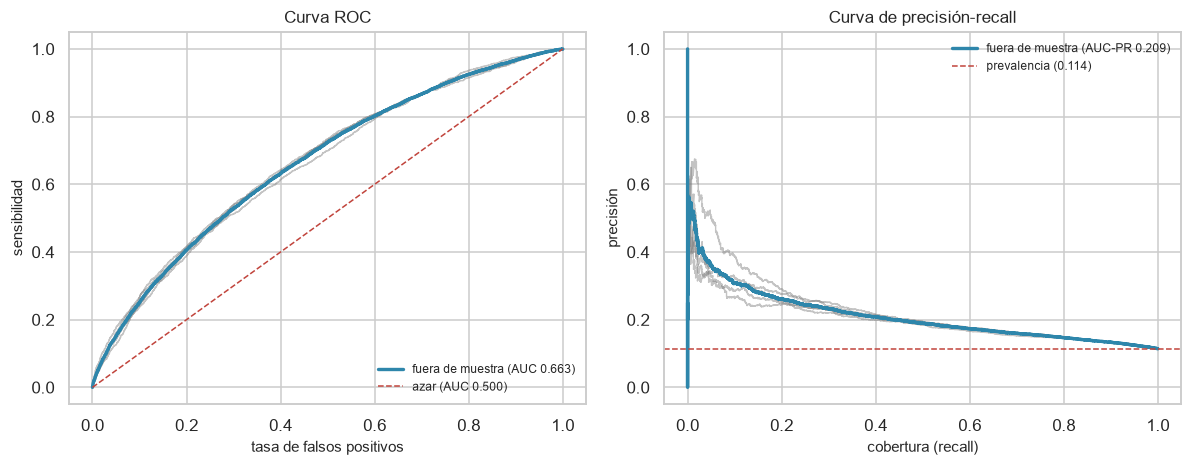

'1.84'

In [5]:
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.4))

for i in range(1, 6):
    m = fold_de_fila == i
    fpr, tpr, _ = roc_curve(y[m], probabilidades[m])
    ejes[0].plot(fpr, tpr, color=GRIS, alpha=0.45, linewidth=0.9)
    precision, cobertura, _ = precision_recall_curve(y[m], probabilidades[m])
    ejes[1].plot(cobertura, precision, color=GRIS, alpha=0.45, linewidth=0.9)

fpr, tpr, _ = roc_curve(y, probabilidades)
ejes[0].plot(fpr, tpr, color=PALETA[0], linewidth=2.2,
             label=f"fuera de muestra (AUC {roc_auc_score(y, probabilidades):.3f})")
ejes[0].plot([0, 1], [0, 1], color=PALETA[1], linestyle="--", linewidth=1,
             label="azar (AUC 0.500)")
ejes[0].set_xlabel("tasa de falsos positivos")
ejes[0].set_ylabel("sensibilidad")
ejes[0].set_title("Curva ROC")
ejes[0].legend(loc="lower right", fontsize=8)

precision, cobertura, _ = precision_recall_curve(y, probabilidades)
ejes[1].plot(cobertura, precision, color=PALETA[0], linewidth=2.2,
             label=f"fuera de muestra (AUC-PR {average_precision_score(y, probabilidades):.3f})")
ejes[1].axhline(PREVALENCIA, color=PALETA[1], linestyle="--", linewidth=1,
                label=f"prevalencia ({PREVALENCIA:.3f})")
ejes[1].set_xlabel("cobertura (recall)")
ejes[1].set_ylabel("precisión")
ejes[1].set_title("Curva de precisión-recall")
ejes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

anotar("c7_auc_roc_pooled", f"{roc_auc_score(y, probabilidades):.4f}")
anotar("c7_auc_pr_pooled",
       f"{average_precision_score(y, probabilidades):.4f}")
anotar("c7_ganancia_pr",
       f"{average_precision_score(y, probabilidades) / PREVALENCIA:.2f}")

Las cinco curvas por fold se superponen estrechamente, lo que confirma numéricamente lo que las desviaciones estándar de la tabla anterior ya indicaban: la estimación no depende de la partición. En la curva de precisión-recall se aprecia el rasgo que gobierna el uso práctico del modelo: la precisión decae con rapidez al aumentar la cobertura, de modo que cualquier intervención que aspire a capturar a la mayoría de los reingresos tendrá que aceptar una mayoría de falsos positivos. El AUC-PR fuera de muestra, {glue:text}`c7_auc_pr_pooled`, equivale a {glue:text}`c7_ganancia_pr` veces la prevalencia.

### 7.2.2. ¿El modelo gana su complejidad?

Una cifra de desempeño aislada no se interpreta. La comparación pertinente no es contra el 1.0 ideal sino contra lo que se obtendría sin modelo, con un solo predictor, y con el techo que el análisis exploratorio estimó para este problema. Las cuatro referencias provienen de los capítulos anteriores y están calculadas con la misma validación agrupada, lo que las hace comparables entre sí.

In [6]:
def referencia_eda(archivo, extraer, respaldo):
    """Lee una referencia de los resultados del EDA, con respaldo documentado.

    Los capítulos 4 y 5 guardaron sus tablas en ``results/``. Si el notebook
    se ejecuta antes que ellos, se usa el valor publicado en esos capítulos
    para que el capítulo siga siendo ejecutable de forma aislada.
    """
    try:
        return extraer(pd.read_csv(RESULTADOS / f"{archivo}.csv")), "calculada"
    except (FileNotFoundError, KeyError, IndexError, ValueError):
        return respaldo, "publicada en el capítulo"


auc_univariado, origen_univariado = referencia_eda(
    "ranking_predictores",
    lambda d: d["AUC univariado"].max(), 0.6072)
auc_oraculo, origen_oraculo = referencia_eda(
    "techo_desempeno",
    lambda d: d["AUC del oráculo (fuera de muestra)"].max(), 0.6512)

auc_base = roc_auc_score(y, probabilidades)
pr_base = average_precision_score(y, probabilidades)

referencias = pd.DataFrame([
    {"Referencia": "Clasificador constante (predice la prevalencia)",
     "AUC-ROC": 0.5, "AUC-PR": PREVALENCIA,
     "Procedencia": "definición"},
    {"Referencia": "Mejor predictor individual (number_inpatient)",
     "AUC-ROC": auc_univariado, "AUC-PR": np.nan,
     "Procedencia": f"capítulo 4, {origen_univariado}"},
    {"Referencia": "Oráculo por perfiles (techo estimado)",
     "AUC-ROC": auc_oraculo, "AUC-PR": np.nan,
     "Procedencia": f"sección 5.4, {origen_oraculo}"},
    {"Referencia": "Modelo base (esta logística)",
     "AUC-ROC": auc_base, "AUC-PR": pr_base,
     "Procedencia": "sección 7.2"},
]).set_index("Referencia").round(4)

guardar_resultado(referencias, "modelo_base_referencias")
anotar("c7_univariado", f"{auc_univariado:.4f}")
anotar("c7_oraculo", f"{auc_oraculo:.4f}")
anotar("c7_sobre_univariado", f"{1000 * (auc_base - auc_univariado):.0f}")
anotar("c7_sobre_oraculo", f"{1000 * (auc_base - auc_oraculo):.0f}")
referencias

,AUC-ROC,AUC-PR,Procedencia
Referencia,,,
Clasificador constante (predice la prevalencia),0.5000,0.1139,definición
Mejor predictor individual (number_inpatient),0.6072,NaN,"capítulo 4, calculada"
Oráculo por perfiles (techo estimado),0.6507,NaN,"sección 5.4, calculada"
Modelo base (esta logística),0.6634,0.2094,sección 7.2


El modelo base supera al mejor predictor individual, cuyo AUC era {glue:text}`c7_univariado`, en {glue:text}`c7_sobre_univariado` milésimas, y al oráculo por perfiles, con AUC {glue:text}`c7_oraculo`, en {glue:text}`c7_sobre_oraculo`. Las dos comparaciones dicen cosas distintas y ambas importan.

Superar al predictor individual demuestra que la combinación multivariada aporta: hay información en el resto de las variables que `number_inpatient` no contiene, aunque ninguna de ellas por separado discrimine gran cosa. Superar al oráculo por perfiles es el resultado más informativo, porque el oráculo era un límite superior aparente. La sección 5.4 construyó un clasificador que memorizaba la tasa de readmisión de cada perfil de predictores y comprobó que su desempeño **se derrumba** al añadir variables: con ocho predictores los perfiles se multiplican hasta casi quince mil y cada uno queda estimado con un puñado de encuentros. La logística usa las mismas variables y no sufre esa caída, porque no trata los perfiles como categorías independientes: impone una forma funcional que comparte información entre perfiles parecidos, y la penalización L1 anula lo que no aporta. Esa es exactamente la predicción que la sección 5.4 formuló, y aquí queda confirmada.

La consecuencia para los capítulos siguientes es una expectativa, no un pronóstico: el margen disponible por encima de {glue:text}`c7_auc_roc_pooled` es estrecho. Si un ensamble de árboles gana, ganará por centésimas.

## 7.3. Qué aprendió el modelo

### 7.3.1. La selección de variables que hace la penalización L1

La penalización L1 añade a la función de pérdida la suma de los valores absolutos de los coeficientes. A diferencia de la L2, que encoge todos los coeficientes hacia cero sin llegar a anularlos, la L1 los lleva exactamente a cero cuando su aporte no compensa la penalización. El número de coeficientes nulos es entonces una lectura directa de cuántas columnas de la matriz de diseño el modelo considera prescindibles.

In [7]:
promedio = coeficientes.mean(axis=0)
nulos_por_fold = (coeficientes == 0).sum(axis=1)
nulos_siempre = (coeficientes == 0).all(axis=0).sum()

dispersion = pd.DataFrame({
    "columnas anuladas": nulos_por_fold,
    "% de la matriz": (100 * nulos_por_fold / coeficientes.shape[1]).round(1),
})
dispersion.loc["anuladas en los cinco folds"] = [
    nulos_siempre, round(100 * nulos_siempre / coeficientes.shape[1], 1)]

print(f"Columnas de la matriz de diseño : {coeficientes.shape[1]}")
print(f"Anuladas en algún fold          : {(coeficientes == 0).any(axis=0).sum()}")
print(f"Anuladas en los cinco folds     : {nulos_siempre}")
print(f"Coeficiente de mayor magnitud   : {promedio.abs().max():.3f}")

anotar("c7_nulos", int(nulos_siempre))
anotar("c7_nulos_pct", f"{100 * nulos_siempre / coeficientes.shape[1]:.0f}")
anotar("c7_nulos_fold", f"{nulos_por_fold.mean():.0f}")
anotar("c7_nulos_fold_pct",
       f"{100 * nulos_por_fold.mean() / coeficientes.shape[1]:.0f}")
anotar("c7_nulos_alguno", int((coeficientes == 0).any(axis=0).sum()))
dispersion

Columnas de la matriz de diseño : 152
Anuladas en algún fold          : 90
Anuladas en los cinco folds     : 18
Coeficiente de mayor magnitud   : 0.982


,columnas anuladas,% de la matriz
fold 1,54.0,35.5
fold 2,56.0,36.8
fold 3,47.0,30.9
fold 4,56.0,36.8
fold 5,51.0,33.6
anuladas en los cinco folds,18.0,11.8


La tabla contiene el hallazgo más interesante del capítulo, y está en el contraste entre sus dos filas. En cada fold la penalización anula alrededor de {glue:text}`c7_nulos_fold` columnas, el {glue:text}`c7_nulos_fold_pct` % de la matriz: el modelo efectivamente descarta un tercio de lo que recibe. Pero solo {glue:text}`c7_nulos` columnas, el {glue:text}`c7_nulos_pct` % de las {glue:text}`c7_columnas`, quedan anuladas en **los cinco folds** a la vez, mientras {glue:text}`c7_nulos_alguno` lo están en alguno.

Es decir: el modelo siempre descarta un tercio de las columnas, pero no siempre las mismas. La selección de variables que hace L1 es inestable, y esa inestabilidad no es un defecto del ajuste sino un comportamiento conocido de la penalización L1 cuando hay predictores correlacionados. Ante un grupo de columnas que aportan información solapada, L1 tiende a conservar una y anular el resto, y cuál conserva depende de fluctuaciones pequeñas en los datos. La sección 4.3 documentó precisamente esa redundancia entre las categóricas, y la sección 5.3 encontró veintisiete dependencias lineales exactas en la matriz de diseño por efecto de la codificación one-hot sin categoría de referencia.

La consecuencia es una advertencia para el capítulo 10, que estudiará la interpretabilidad del modelo final: **la lista de variables seleccionadas por L1 no debe leerse como un conjunto de factores de riesgo**. Lo estable aquí es el desempeño y el signo de los coeficientes grandes, no la identidad de las columnas que sobreviven. Para afirmaciones sobre importancia de variables hacen falta métodos que reparten el crédito entre predictores correlacionados en lugar de elegir uno, que es lo que aportan los valores de Shapley del capítulo 10.

### 7.3.2. Razones de momios de las variables con mayor peso

Un coeficiente de la logística es el cambio en el logaritmo de los momios de readmisión por un incremento unitario de la variable, con las demás fijas. Su exponencial es la razón de momios: un valor de 1.5 significa que los momios de readmisión se multiplican por 1.5. Para las variables numéricas el incremento unitario es una desviación robusta, porque `RobustScaler` las dividió por el rango intercuartílico; para las columnas one-hot es la presencia de la categoría frente a la de referencia.

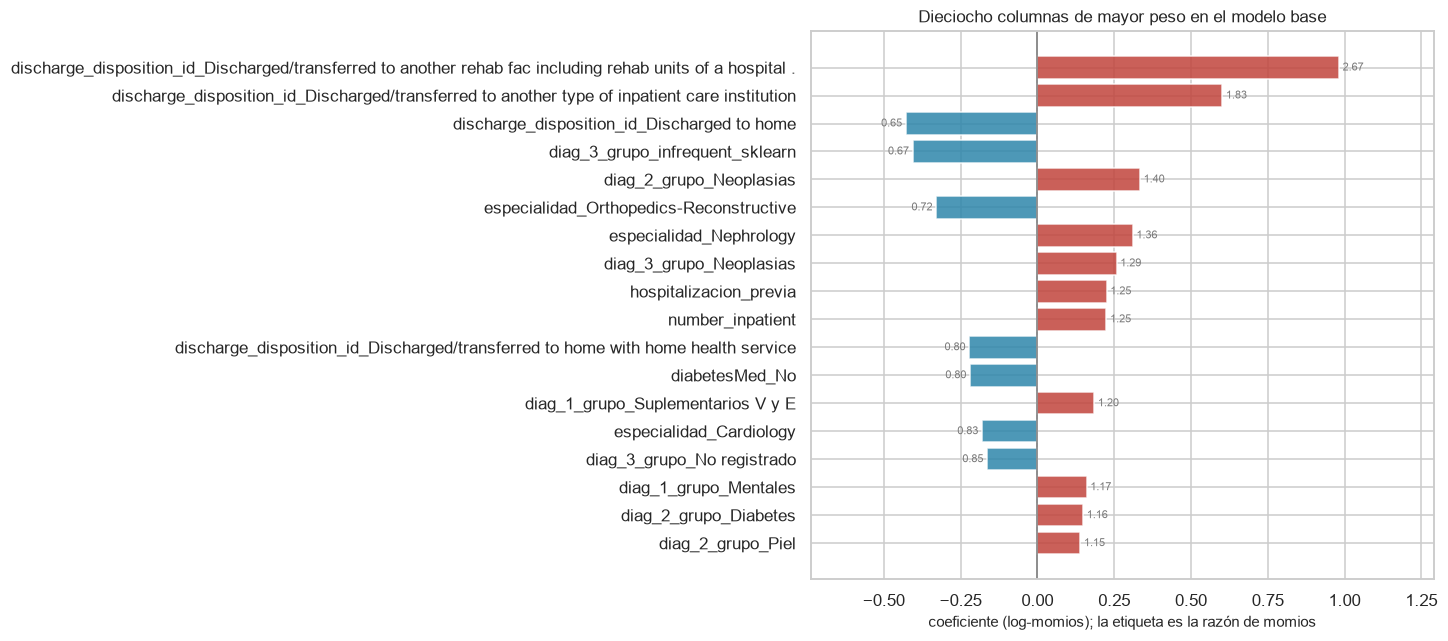

### Quince columnas de mayor magnitud

In [8]:
efectos = pd.DataFrame({
    "coeficiente": promedio,
    "razón de momios": np.exp(promedio),
    "signo estable": [(np.sign(coeficientes[c]) == np.sign(promedio[c])).all()
                      and promedio[c] != 0 for c in coeficientes.columns],
})
efectos["|coeficiente|"] = efectos["coeficiente"].abs()
efectos = efectos.sort_values("|coeficiente|", ascending=False)

principales = efectos.head(18).iloc[::-1]
colores_barras = [PALETA[1] if v > 0 else PALETA[0]
                  for v in principales["coeficiente"]]

fig, eje = plt.subplots(figsize=(9, 6))
eje.barh(principales.index, principales["coeficiente"],
         color=colores_barras, alpha=0.85)
eje.axvline(0, color=GRIS, linewidth=1)
for nombre, fila in principales.iterrows():
    desplazamiento = 0.012 if fila["coeficiente"] > 0 else -0.012
    eje.text(fila["coeficiente"] + desplazamiento, nombre,
             f"{fila['razón de momios']:.2f}", va="center", fontsize=7.5,
             ha="left" if fila["coeficiente"] > 0 else "right", color=GRIS)
eje.set_xlabel("coeficiente (log-momios); la etiqueta es la razón de momios")
eje.set_title("Dieciocho columnas de mayor peso en el modelo base")
eje.margins(x=0.22)
fig.subplots_adjust(left=0.34, right=0.97, top=0.93, bottom=0.1)
plt.show()

guardar_resultado(efectos.drop(columns="|coeficiente|").head(30),
                  "modelo_base_coeficientes")
mayor = efectos.index[0]
A_CASA = "discharge_disposition_id_Discharged to home"

anotar("c7_mayor_or", f"{efectos.loc[mayor, 'razón de momios']:.2f}")
anotar("c7_top_alta",
       int(efectos.head(5).index.str.startswith(
           "discharge_disposition_id").sum()))
anotar("c7_or_casa", f"{efectos.loc[A_CASA, 'razón de momios']:.2f}"
       if A_CASA in efectos.index else "no disponible")
anotar("c7_estables", int(efectos["signo estable"].sum()))
tabla(efectos.drop(columns="|coeficiente|").head(15).round(3), filas=15,
      titulo="Quince columnas de mayor magnitud")

El resultado dominante es el destino al alta: {glue:text}`c7_top_alta` de las cinco columnas de mayor magnitud provienen de `discharge_disposition_id`. La de mayor peso corresponde al traslado a una unidad de rehabilitación, con una razón de momios de {glue:text}`c7_mayor_or`, es decir que multiplica por más de dos y medio los momios de readmisión frente a la categoría de referencia. En el extremo opuesto, el alta a domicilio tiene una razón de momios de {glue:text}`c7_or_casa`, claramente protectora.

Esa jerarquía tiene una lectura clínica directa y coherente: el destino al alta es, en buena medida, un resumen que el propio sistema de salud produce sobre la fragilidad del paciente. Un traslado a otra institución de cuidados codifica que el equipo tratante consideró que el paciente no podía volver a casa, y eso concentra más información sobre el riesgo de reingreso que cualquier variable clínica individual del registro. Las variables de utilización previa (`number_inpatient` y `hospitalizacion_previa`, con razones de momios en torno a 1.25) aparecen a continuación, y su dirección coincide con la que el capítulo 4 midió.

En {glue:text}`c7_estables` de las {glue:text}`c7_columnas` columnas el coeficiente es no nulo y conserva el mismo signo en los cinco folds, de modo que la dirección de los efectos grandes no es un artefacto de la partición, aunque la sección anterior ya advirtió que la identidad de las columnas *pequeñas* sí lo es.

Una advertencia sobre la lectura. Estos coeficientes son asociaciones condicionales dentro de un modelo lineal, no efectos causales, y el caso del destino al alta lo ilustra bien: no es que trasladar a un paciente a rehabilitación cause su reingreso, sino que ambas cosas responden a una gravedad que el registro no mide directamente. La sección 4.4 documentó un caso análogo con la medición de hemoglobina glicosilada, cuyo estado discrimina el desenlace y admite dos lecturas no exclusivas, un proceso de atención más cuidadoso o una confusión por indicación. Un coeficiente no distingue entre ambas.

### 7.3.3. Coherencia con el ordenamiento del capítulo 4

Aquí se cierra un circuito. El capítulo 4 ordenó los predictores con estadísticos univariados, sin ajustar por las demás variables. El modelo base los pondera de forma conjunta. Si los dos ordenamientos coincidieran perfectamente, el análisis multivariado no habría aportado nada; si fueran independientes, el análisis exploratorio habría sido inútil como guía. Lo interesante está en el medio, y en identificar qué variables cambian de lugar.

Para comparar, las columnas one-hot se agrupan de vuelta en la variable de origen y se toma el coeficiente de mayor magnitud de cada grupo. El mapeo no puede darse por supuesto a partir del orden de los bloques: el preprocesador trata `race` en un bloque propio, sin agrupación por frecuencia, porque el capítulo 2 la eximió del umbral del 1 % para conservar desagregado el grupo `Asian`. Se reconstruye entonces asociando cada columna con el nombre de predictor más largo que la prefija, criterio que resuelve correctamente casos como `glyburide-metformin_No`, que un corte por el primer guion bajo atribuiría a `glyburide`.

152 columnas asociadas a 38 variables de origen


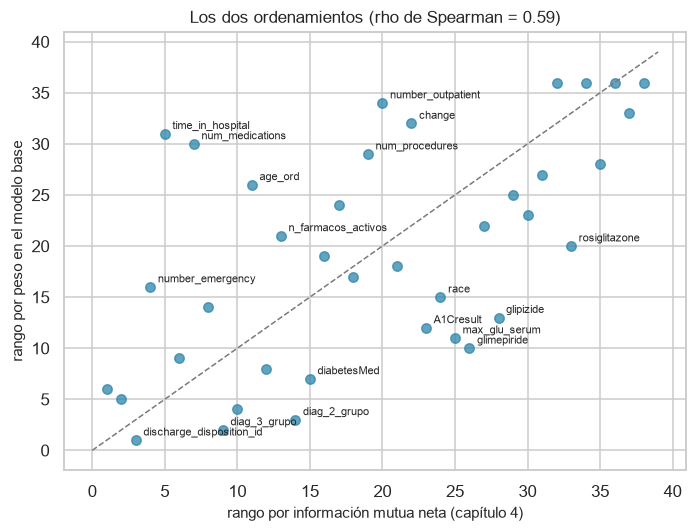

### Comparación de ordenamientos

In [9]:
def mapa_de_origen(preprocesador, predictores):
    """Asocia cada columna de la matriz con la variable que la generó.

    La correspondencia se establece por el prefijo más largo, de modo que el
    resultado no depende del orden ni del número de bloques del
    ``ColumnTransformer``.
    """
    nombres = ex.nombres_variables(preprocesador)
    candidatos = sorted(predictores, key=len, reverse=True)
    origen = {}
    for columna in nombres:
        for variable in candidatos:
            if columna == variable or columna.startswith(f"{variable}_"):
                origen[columna] = variable
                break
        else:
            raise ValueError(f"columna sin variable de origen: {columna}")
    return origen


preprocesador_ajustado = ex.construir_preprocesador(roles).fit(X)
origen = mapa_de_origen(preprocesador_ajustado, PREDICTORES)
print(f"{len(origen)} columnas asociadas a "
      f"{len(set(origen.values()))} variables de origen")

por_variable = (efectos.assign(variable=[origen[c] for c in efectos.index])
                .groupby("variable", observed=True)["|coeficiente|"]
                .max().sort_values(ascending=False))

ranking_eda = pd.read_csv(RESULTADOS / "ranking_predictores.csv") \
    if (RESULTADOS / "ranking_predictores.csv").exists() else None

if ranking_eda is not None:
    comparacion = (ranking_eda.set_index("variable")[["información mutua neta",
                                                      "AUC univariado"]]
                   .join(por_variable.rename("peso en el modelo base"),
                         how="inner")
                   .dropna(subset=["peso en el modelo base"]))
    comparacion["rango en el capítulo 4"] = (
        comparacion["información mutua neta"].rank(ascending=False).astype(int))
    comparacion["rango en el modelo base"] = (
        comparacion["peso en el modelo base"].rank(ascending=False).astype(int))
    comparacion["desplazamiento"] = (comparacion["rango en el capítulo 4"]
                                     - comparacion["rango en el modelo base"])
    rho = stats.spearmanr(comparacion["información mutua neta"],
                          comparacion["peso en el modelo base"]).statistic

    fig, eje = plt.subplots(figsize=(6.5, 5))
    eje.scatter(comparacion["rango en el capítulo 4"],
                comparacion["rango en el modelo base"],
                color=PALETA[0], alpha=0.75, s=38)
    limite = comparacion[["rango en el capítulo 4",
                          "rango en el modelo base"]].to_numpy().max() + 1
    eje.plot([0, limite], [0, limite], color=GRIS, linestyle="--", linewidth=1)
    for nombre, fila in comparacion.iterrows():
        if abs(fila["desplazamiento"]) >= 8 or fila["rango en el modelo base"] <= 3:
            eje.annotate(nombre, (fila["rango en el capítulo 4"],
                                  fila["rango en el modelo base"]),
                         textcoords="offset points", xytext=(5, 3), fontsize=7.5)
    eje.set_xlabel("rango por información mutua neta (capítulo 4)")
    eje.set_ylabel("rango por peso en el modelo base")
    eje.set_title(f"Los dos ordenamientos (rho de Spearman = {rho:.2f})")
    plt.tight_layout()
    plt.show()

    ascensos = comparacion.nlargest(3, "desplazamiento")
    descensos = comparacion.nsmallest(3, "desplazamiento")
    guardar_resultado(comparacion.round(4), "modelo_base_vs_eda")

    anotar("c7_rho", f"{rho:.2f}")
    anotar("c7_asciende", ascensos.index[0])
    anotar("c7_asciende_puestos", int(ascensos["desplazamiento"].iloc[0]))
    anotar("c7_desciende", descensos.index[0])
    anotar("c7_desciende_puestos", int(-descensos["desplazamiento"].iloc[0]))
    anotar("c7_desciende2", descensos.index[1])
    anotar("c7_desciende2_puestos", int(-descensos["desplazamiento"].iloc[1]))
    primera = comparacion.sort_values("rango en el modelo base").index[0]
    anotar("c7_primera", primera)
    anotar("c7_primera_eda",
           int(comparacion.loc[primera, "rango en el capítulo 4"]))
    tabla(comparacion.sort_values("rango en el modelo base").head(12).round(4),
          filas=12, titulo="Comparación de ordenamientos")
else:
    print("results/ranking_predictores.csv no disponible: ejecute el capítulo 4.")
    for clave in ["c7_rho", "c7_asciende", "c7_asciende_puestos",
                  "c7_desciende", "c7_desciende_puestos", "c7_desciende2",
                  "c7_desciende2_puestos", "c7_primera", "c7_primera_eda"]:
        anotar(clave, "no disponible")

La correlación de Spearman entre los dos ordenamientos es {glue:text}`c7_rho`: una coincidencia moderada, ni redundante ni nula. El análisis exploratorio acertó en lo importante, y `{glue:text}`c7_primera``, que era la posición {glue:text}`c7_primera_eda` del capítulo 4, encabeza el modelo. Pero el reordenamiento es considerable, y merece leerse por separado en cada dirección.

**Los descensos son el hallazgo sólido.** `{glue:text}`c7_desciende`` pierde {glue:text}`c7_desciende_puestos` puestos y `{glue:text}`c7_desciende2`` pierde {glue:text}`c7_desciende2_puestos`. Las dos son variables de intensidad del episodio, fuertemente asociadas entre sí y con el resto de las variables de utilización. Su señal univariada era real, pero estaba contenida en otros predictores: una vez que el modelo dispone de todos, deja de necesitarlas. Es la contrapartida directa de la redundancia que midió la sección 4.3 y la razón por la que un ranking univariado nunca debe usarse para seleccionar variables.

**Los ascensos piden cautela.** El mayor corresponde a `{glue:text}`c7_asciende``, que gana {glue:text}`c7_asciende_puestos` puestos, y la mayoría de los ascensos pronunciados son fármacos cuya información mutua neta univariada es prácticamente nula. Hay dos explicaciones posibles y este capítulo no puede distinguirlas: un efecto condicional genuino, visible solo tras controlar el resto, o un coeficiente ajustado al ruido de categorías poco frecuentes. Que la sección anterior haya encontrado la selección de L1 inestable entre folds inclina la balanza hacia la segunda, y es una razón más para no leer estos coeficientes como una lista de factores de riesgo.

El valor de la comparación no está entonces en validar el análisis exploratorio, sino en delimitar para qué sirvió: fue una guía fiable sobre **dónde hay señal** y una guía poco fiable sobre **cuánto aporta cada variable** en presencia de las demás.

## 7.4. Cómo se equivoca el modelo

### 7.4.1. La matriz de confusión depende del umbral

Todas las métricas de conteo (exactitud, precisión, cobertura, F1) exigen convertir una probabilidad en una decisión, y esa conversión requiere un umbral. El 0.5 es una convención, no una elección: con `class_weight="balanced"` el ajuste desplaza las probabilidades hacia el centro, y en un problema con un 11 % de positivos el umbral que optimiza cualquier criterio operativo casi nunca es 0.5. Se comparan tres umbrales, con la misma predicción fuera de muestra.

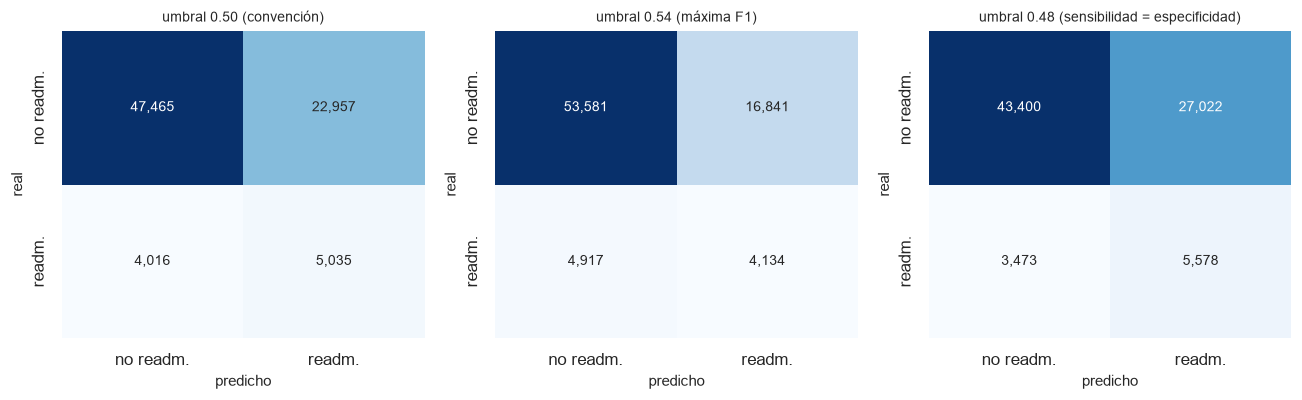

,alertas emitidas,precisión (%),cobertura (%),F1,falsos negativos
umbral,,,,,
0.50 (convención),27992,17.987,55.629,0.272,4016
0.54 (máxima F1),20975,19.709,45.675,0.275,4917
0.48 (sensibilidad = especificidad),32600,17.110,61.629,0.268,3473


In [10]:
from sklearn.metrics import confusion_matrix, f1_score

umbrales = np.linspace(0.05, 0.95, 181)
f1_por_umbral = [f1_score(y, probabilidades >= u, zero_division=0)
                 for u in umbrales]
umbral_f1 = umbrales[int(np.argmax(f1_por_umbral))]

# Umbral que iguala sensibilidad y especificidad: el punto de la ROC donde
# los dos tipos de error se equilibran en términos relativos.
fpr, tpr, cortes = roc_curve(y, probabilidades)
umbral_equilibrado = cortes[int(np.argmin(np.abs(tpr - (1 - fpr))))]

seleccionados = {
    "0.50 (convención)": 0.50,
    f"{umbral_f1:.2f} (máxima F1)": umbral_f1,
    f"{umbral_equilibrado:.2f} (sensibilidad = especificidad)": umbral_equilibrado,
}

fig, ejes = plt.subplots(1, 3, figsize=(12, 3.8))
filas = []
for eje, (etiqueta, umbral) in zip(ejes, seleccionados.items()):
    prediccion = (probabilidades >= umbral).astype(int)
    matriz = confusion_matrix(y, prediccion)
    sns.heatmap(matriz, annot=True, fmt=",d", cbar=False, ax=eje,
                cmap="Blues", annot_kws={"size": 9},
                xticklabels=["no readm.", "readm."],
                yticklabels=["no readm.", "readm."])
    eje.set_title(f"umbral {etiqueta}", fontsize=9)
    eje.set_xlabel("predicho")
    eje.set_ylabel("real")
    vn, fp, fn, vp = matriz.ravel()
    filas.append({
        "umbral": etiqueta,
        "alertas emitidas": vp + fp,
        "precisión (%)": 100 * vp / max(vp + fp, 1),
        "cobertura (%)": 100 * vp / max(vp + fn, 1),
        "F1": f1_score(y, prediccion, zero_division=0),
        "falsos negativos": fn,
    })
plt.tight_layout()
plt.show()

comparacion_umbrales = pd.DataFrame(filas).set_index("umbral").round(3)
guardar_resultado(comparacion_umbrales, "modelo_base_umbrales")
anotar("c7_umbral_f1", f"{umbral_f1:.2f}")
anotar("c7_f1_max", f"{max(f1_por_umbral):.3f}")
anotar("c7_f1_convencion", f"{f1_score(y, probabilidades >= 0.5):.3f}")
anotar("c7_umbral_equilibrado", f"{umbral_equilibrado:.2f}")
anotar("c7_alertas_f1",
       f"{comparacion_umbrales['alertas emitidas'].iloc[1]:,}")
anotar("c7_alertas_eq",
       f"{comparacion_umbrales['alertas emitidas'].iloc[2]:,}")
anotar("c7_fn_eq", f"{comparacion_umbrales['falsos negativos'].iloc[2]:,}")
anotar("c7_fn_f1", f"{comparacion_umbrales['falsos negativos'].iloc[1]:,}")
comparacion_umbrales

El umbral que maximiza F1 es {glue:text}`c7_umbral_f1`, por encima del 0.5 convencional, pero la ganancia es irrelevante: F1 pasa de {glue:text}`c7_f1_convencion` a {glue:text}`c7_f1_max`. Como la superficie de validación de la sección 7.1.3, el criterio F1 también es plano, y por la misma razón de fondo: el modelo ordena los encuentros con una separación modesta, de modo que mover el corte reparte los errores entre los dos tipos sin reducir su total.

Lo que la tabla sí muestra con claridad es la magnitud de ese reparto. Entre el umbral de máxima F1 y el que equilibra sensibilidad y especificidad ({glue:text}`c7_umbral_equilibrado`) hay una diferencia de seis centésimas en el corte y, sin embargo, las alertas emitidas pasan de {glue:text}`c7_alertas_f1` a {glue:text}`c7_alertas_eq`, y los reingresos no anticipados bajan de {glue:text}`c7_fn_f1` a {glue:text}`c7_fn_eq`. Ninguna de las tres columnas es la correcta en abstracto: la elección depende del costo relativo de un reingreso no anticipado frente al de un seguimiento innecesario, que es una decisión clínica y presupuestaria, no estadística.

Ese es también el argumento para no informar F1 ni exactitud como métrica de comparación en los capítulos siguientes. Ambas fijan implícitamente un costo relativo (F1 iguala precisión y cobertura; la exactitud pondera por la prevalencia) y lo hacen sin declararlo. El capítulo 10 formaliza la decisión con una función de costo explícita.

### 7.4.2. La lectura que le sirve a un hospital

Un servicio de gestión de altas no elige un umbral: elige una capacidad. Puede dar seguimiento intensivo a un número fijo de pacientes por semana, y lo que necesita saber es a cuántos reingresos reales llegaría si dedicara esa capacidad a los encuentros de mayor riesgo estimado. Esa es la curva de precisión y cobertura por fracción priorizada, y es la forma en la que este modelo sería realmente utilizable.

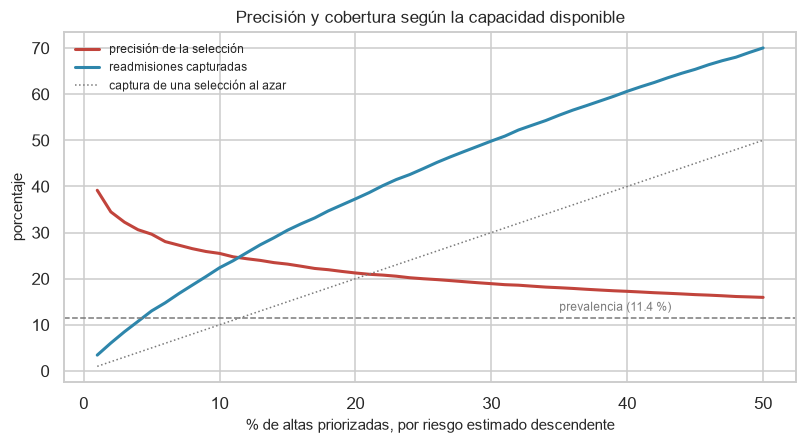

,precisión (%),readmisiones capturadas (%),ganancia sobre el azar
fracción priorizada,,,
5%,29.7,13.0,2.61
10%,25.5,22.4,2.24
20%,21.2,37.3,1.86
30%,18.9,49.8,1.66


In [11]:
orden = np.argsort(-probabilidades)
fracciones = np.arange(0.01, 0.51, 0.01)
precision_acumulada, cobertura_acumulada = [], []
for fraccion in fracciones:
    k = int(len(y) * fraccion)
    seleccion = y.to_numpy()[orden[:k]]
    precision_acumulada.append(100 * seleccion.mean())
    cobertura_acumulada.append(100 * seleccion.sum() / y.sum())

fig, eje = plt.subplots(figsize=(7.5, 4.2))
eje.plot(100 * fracciones, precision_acumulada, color=PALETA[1],
         linewidth=2, label="precisión de la selección")
eje.plot(100 * fracciones, cobertura_acumulada, color=PALETA[0],
         linewidth=2, label="readmisiones capturadas")
eje.axhline(100 * PREVALENCIA, color=GRIS, linestyle="--", linewidth=1)
eje.annotate(f"prevalencia ({100 * PREVALENCIA:.1f} %)",
             xy=(35, 100 * PREVALENCIA), xytext=(0, 5),
             textcoords="offset points", fontsize=8, color=GRIS)
eje.plot(100 * fracciones, 100 * fracciones, color=GRIS, linestyle=":",
         linewidth=1, label="captura de una selección al azar")
eje.set_xlabel("% de altas priorizadas, por riesgo estimado descendente")
eje.set_ylabel("porcentaje")
eje.set_title("Precisión y cobertura según la capacidad disponible")
eje.legend(fontsize=8)
plt.tight_layout()
plt.show()

hitos = pd.DataFrame({
    "fracción priorizada": [f"{f:.0%}" for f in [0.05, 0.10, 0.20, 0.30]],
    "precisión (%)": [precision_acumulada[int(round(f * 100)) - 1]
                      for f in [0.05, 0.10, 0.20, 0.30]],
    "readmisiones capturadas (%)": [cobertura_acumulada[int(round(f * 100)) - 1]
                                    for f in [0.05, 0.10, 0.20, 0.30]],
}).set_index("fracción priorizada").round(1)
hitos["ganancia sobre el azar"] = (
    hitos["precisión (%)"] / (100 * PREVALENCIA)).round(2)

guardar_resultado(hitos, "modelo_base_precision_top")
anotar("c7_precision_10", f"{hitos.loc['10%', 'precisión (%)']:.1f}")
anotar("c7_captura_10",
       f"{hitos.loc['10%', 'readmisiones capturadas (%)']:.1f}")
anotar("c7_ganancia_10", f"{hitos.loc['10%', 'ganancia sobre el azar']:.2f}")
hitos

Si el hospital puede intervenir sobre el 10 % de las altas, atender a las de mayor riesgo estimado da una precisión del {glue:text}`c7_precision_10` % frente al {glue:text}`c7_prevalencia` % de elegir al azar, una ganancia de {glue:text}`c7_ganancia_10` veces, y ese 10 % concentra el {glue:text}`c7_captura_10` % de todas las readmisiones. Dicho de otro modo: con un modelo de AUC 0.66, uno de cada cuatro pacientes priorizados reingresa de verdad, y se anticipa alrededor de una quinta parte del total de reingresos.

Esa es la magnitud realista del beneficio, y conviene fijarla antes de optimizar. Los capítulos siguientes intentarán mejorar el AUC en centésimas; esta tabla es la que traduce esas centésimas en pacientes.

## 7.5. ¿Significan algo las probabilidades?

El AUC solo mide el ordenamiento. Un modelo puede ordenar impecablemente y estar mal calibrado, de modo que su "30 % de riesgo" no corresponda a una readmisión de cada tres. Para una decisión clínica al alta la magnitud importa, porque es la que entra en cualquier cálculo de costo esperado. El diagnóstico se hace con un diagrama de fiabilidad: se agrupan los encuentros por probabilidad predicha y se compara, en cada grupo, la media predicha con la frecuencia observada.

La corrección se ajusta de forma cruzada sobre las propias predicciones fuera de muestra: para cada fold, el calibrador se estima con las predicciones de los otros cuatro y se aplica a las de este. Así la mejora que se reporta no es el resultado de calibrar y evaluar sobre los mismos datos, y no requiere reajustar el modelo.

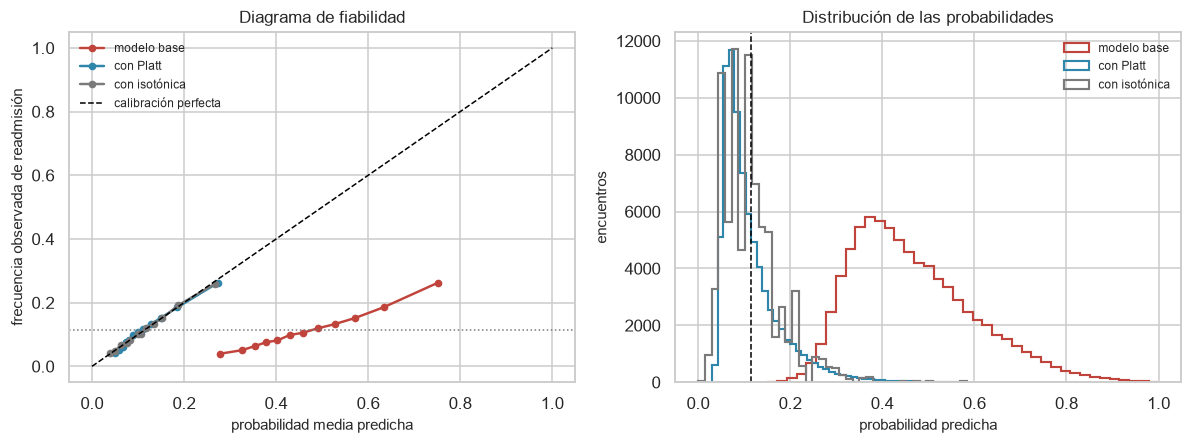

,Brier,AUC-ROC,AUC-PR,probabilidad media
predicción,,,,
modelo base,0.2266,0.6634,0.2094,0.4668
con Platt,0.0970,0.6633,0.2092,0.1138
con isotónica,0.0970,0.6615,0.2062,0.1138
constante en la prevalencia,0.1009,0.5000,0.1139,0.1139


In [12]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss


def calibrar_cruzado(probas, objetivo, folds, metodo):
    """Calibra las predicciones de cada fold con las de los demás."""
    salida = np.zeros_like(probas)
    for i in np.unique(folds):
        entrena, aplica = folds != i, folds == i
        if metodo == "platt":
            calibrador = LogisticRegression()
            calibrador.fit(probas[entrena].reshape(-1, 1), objetivo[entrena])
            salida[aplica] = calibrador.predict_proba(
                probas[aplica].reshape(-1, 1))[:, 1]
        else:
            calibrador = IsotonicRegression(out_of_bounds="clip")
            calibrador.fit(probas[entrena], objetivo[entrena])
            salida[aplica] = calibrador.predict(probas[aplica])
    return salida


objetivo = y.to_numpy()
platt = calibrar_cruzado(probabilidades, objetivo, fold_de_fila, "platt")
isotonica = calibrar_cruzado(probabilidades, objetivo, fold_de_fila, "isotonica")

variantes = {
    "modelo base": (probabilidades, PALETA[1]),
    "con Platt": (platt, PALETA[0]),
    "con isotónica": (isotonica, GRIS),
}

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))
for etiqueta, (probas, color) in variantes.items():
    observada, predicha = calibration_curve(objetivo, probas, n_bins=12,
                                            strategy="quantile")
    ejes[0].plot(predicha, observada, marker="o", markersize=4, color=color,
                 linewidth=1.6, label=etiqueta)
    ejes[1].hist(probas, bins=40, histtype="step", color=color, linewidth=1.4,
                 label=etiqueta)

ejes[0].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1,
             label="calibración perfecta")
ejes[0].axhline(PREVALENCIA, color=GRIS, linestyle=":", linewidth=1)
ejes[0].set_xlabel("probabilidad media predicha")
ejes[0].set_ylabel("frecuencia observada de readmisión")
ejes[0].set_title("Diagrama de fiabilidad")
ejes[0].legend(fontsize=8)
ejes[1].axvline(PREVALENCIA, color="black", linestyle="--", linewidth=1)
ejes[1].set_xlabel("probabilidad predicha")
ejes[1].set_ylabel("encuentros")
ejes[1].set_title("Distribución de las probabilidades")
ejes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

brier_constante = brier_score_loss(objetivo, np.full(len(objetivo), PREVALENCIA))
calibracion = pd.DataFrame([
    {"predicción": etiqueta,
     "Brier": brier_score_loss(objetivo, probas),
     "AUC-ROC": roc_auc_score(objetivo, probas),
     "AUC-PR": average_precision_score(objetivo, probas),
     "probabilidad media": probas.mean()}
    for etiqueta, (probas, _) in variantes.items()
] + [{"predicción": "constante en la prevalencia", "Brier": brier_constante,
      "AUC-ROC": 0.5, "AUC-PR": PREVALENCIA,
      "probabilidad media": PREVALENCIA}]).set_index("predicción").round(4)

guardar_resultado(calibracion, "modelo_base_calibracion")
anotar("c7_brier_base", f"{calibracion.loc['modelo base', 'Brier']:.4f}")
anotar("c7_brier_platt", f"{calibracion.loc['con Platt', 'Brier']:.4f}")
anotar("c7_brier_iso", f"{calibracion.loc['con isotónica', 'Brier']:.4f}")
anotar("c7_brier_constante", f"{brier_constante:.4f}")
anotar("c7_media_base",
       f"{calibracion.loc['modelo base', 'probabilidad media']:.3f}")
anotar("c7_auc_iso", f"{calibracion.loc['con isotónica', 'AUC-ROC']:.4f}")
calibracion

El diagnóstico es inequívoco. La probabilidad media que asigna el modelo base es {glue:text}`c7_media_base`, frente a una prevalencia real de {glue:text}`c7_prevalencia` %: el modelo sobreestima el riesgo de forma sistemática, por un factor cercano a cuatro. Su coeficiente de Brier, {glue:text}`c7_brier_base`, es mucho peor que el {glue:text}`c7_brier_constante` que obtendría un predictor constante igual a la prevalencia, y el diagrama de fiabilidad queda muy por encima de la diagonal en todo el rango.

Esto no es un defecto del modelo sino la consecuencia esperada de `class_weight="balanced"`. Ponderar la clase minoritaria por el inverso de su frecuencia equivale a ajustar sobre una población donde las readmisiones serían la mitad de los casos, y el intercepto resultante corresponde a esa población ficticia. El ordenamiento de los encuentros se conserva, que es lo que mide el AUC; lo que se pierde es la interpretabilidad de la magnitud.

Las dos correcciones lo recuperan casi por completo. El Brier baja a {glue:text}`c7_brier_platt` con Platt y a {glue:text}`c7_brier_iso` con la regresión isotónica, por debajo del predictor constante, y el AUC-ROC permanece prácticamente intacto ({glue:text}`c7_auc_iso` con la isotónica). Es la ilustración más limpia posible de que discriminación y calibración son propiedades independientes: la corrección reordena la escala sin reordenar los encuentros.

Dos consecuencias para el resto del proyecto. Primera: las comparaciones entre modelos de los capítulos 8 y 11 deben apoyarse en AUC-ROC y AUC-PR, no en Brier, porque el Brier de un modelo ponderado mide sobre todo cuánta ponderación se aplicó. Segunda: cualquier uso de estas probabilidades como riesgo absoluto exige recalibrar antes, y el capítulo 10 desarrolla ese análisis sobre el modelo ganador.

## 7.6. A quién se equivoca el modelo

La sección 4.8 midió las tasas base de readmisión por atributo protegido y encontró dos cosas que ahora conviene retomar: un patrón no monótono por grupo de edad, y que la categoría de raza no informada tiene la tasa más baja de todas. Un modelo entrenado sobre esas tasas las reproduce, y la pregunta pertinente es si además las amplifica.

La medida se elige con cuidado, porque aquí la métrica es la definición de equidad. Comparar la tasa de selección de cada grupo con su tasa real de readmisión parece natural, pero al fijar una capacidad del 10 % y tener el conjunto una prevalencia del {glue:text}`c7_prevalencia` % esa razón queda por debajo de uno en casi todos los grupos por construcción, y no se interpreta.

La medida que sí se interpreta es la **cobertura**: de las readmisiones que ocurren en un grupo, qué fracción entra en el 10 % priorizado. Es la versión de igualdad de oportunidad para este problema, porque responde a la pregunta que le importa a un paciente que va a reingresar: ¿tenía mi grupo la misma probabilidad de recibir seguimiento que los demás? La referencia es la cobertura global, y toda desviación se mide contra ella.

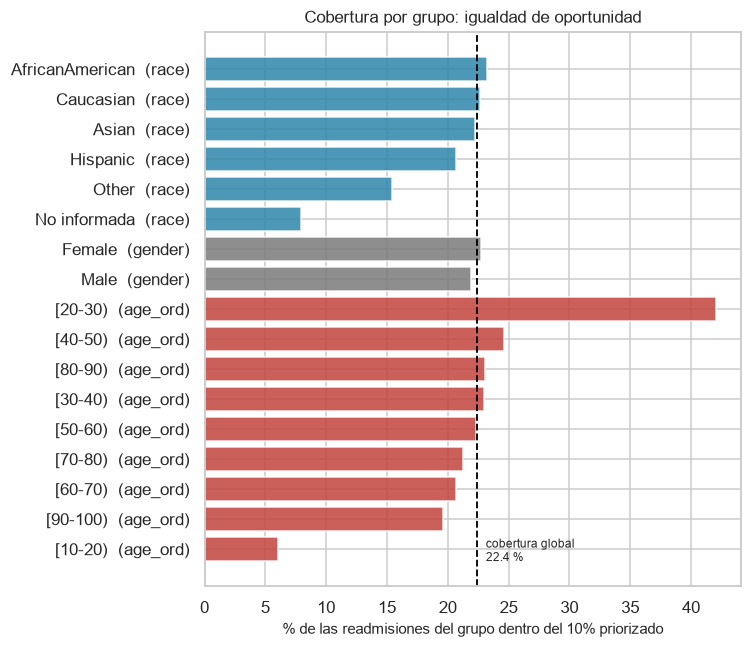

### Cobertura en el 10% priorizado, por grupo

In [13]:
CAPACIDAD = 0.10
corte = np.quantile(probabilidades, 1 - CAPACIDAD)
seleccionado = probabilidades >= corte
cobertura_global = 100 * (seleccionado & (objetivo == 1)).sum() / objetivo.sum()

etiquetas_edad = {int(k): v for k, v in roles["etiquetas_edad"].items()}
filas = []
for atributo in ["race", "gender", "age_ord"]:
    columna = train[atributo]
    if atributo == "age_ord":
        columna = columna.map(etiquetas_edad)
    grupos_atributo = columna.to_numpy()
    for grupo in sorted(pd.unique(grupos_atributo), key=str):
        m = grupos_atributo == grupo
        if m.sum() < 200:
            continue
        real = objetivo[m]
        filas.append({
            "atributo": atributo,
            "grupo": grupo,
            "encuentros": int(m.sum()),
            "tasa real (%)": 100 * real.mean(),
            "tasa de selección (%)": 100 * seleccionado[m].mean(),
            "cobertura (%)": 100 * (seleccionado[m] & (real == 1)).sum()
            / max(real.sum(), 1),
        })

equidad = pd.DataFrame(filas)
equidad["cobertura relativa"] = (equidad["cobertura (%)"]
                                 / cobertura_global).round(2)
equidad = equidad.round(2)

orden_grafico = equidad.sort_values(["atributo", "cobertura (%)"])
colores_atributo = {"race": PALETA[0], "gender": GRIS, "age_ord": PALETA[1]}
fig, eje = plt.subplots(figsize=(8, 6))
eje.barh([f"{f.grupo}  ({f.atributo})" for f in orden_grafico.itertuples()],
         orden_grafico["cobertura (%)"],
         color=[colores_atributo[a] for a in orden_grafico["atributo"]],
         alpha=0.85)
eje.axvline(cobertura_global, color="black", linestyle="--", linewidth=1.2)
eje.annotate(f"cobertura global\n{cobertura_global:.1f} %",
             xy=(cobertura_global, -0.4), xytext=(6, 0),
             textcoords="offset points", fontsize=8)
eje.set_xlabel(f"% de las readmisiones del grupo dentro del "
               f"{CAPACIDAD:.0%} priorizado")
eje.set_title("Cobertura por grupo: igualdad de oportunidad")
fig.subplots_adjust(left=0.36, right=0.97, top=0.93, bottom=0.09)
plt.show()

guardar_resultado(equidad, "modelo_base_equidad")
peor = equidad.loc[equidad["cobertura (%)"].idxmin()]
mejor_grupo = equidad.loc[equidad["cobertura (%)"].idxmax()]

anotar("c7_cobertura_global", f"{cobertura_global:.1f}")
anotar("c7_grupos_evaluados", len(equidad))
anotar("c7_peor_grupo", str(peor["grupo"]))
anotar("c7_peor_cobertura", f"{peor['cobertura (%)']:.1f}")
anotar("c7_peor_tasa", f"{peor['tasa real (%)']:.1f}")
anotar("c7_mejor_grupo", str(mejor_grupo["grupo"]))
anotar("c7_mejor_cobertura", f"{mejor_grupo['cobertura (%)']:.1f}")
anotar("c7_brecha", f"{mejor_grupo['cobertura (%)'] / peor['cobertura (%)']:.1f}")
sin_informar = equidad[equidad["grupo"] == "No informada"]
anotar("c7_cobertura_sininfo",
       f"{sin_informar['cobertura (%)'].iloc[0]:.1f}"
       if len(sin_informar) else "no disponible")

# El mecanismo importa: ¿la baja cobertura viene del coeficiente de la propia
# categoría o del perfil global del grupo en los demás predictores?
COLUMNA_SININFO = "race_No informada"
if COLUMNA_SININFO in efectos.index:
    anotar("c7_coef_sininfo",
           f"{efectos.loc[COLUMNA_SININFO, 'coeficiente']:.3f}")
    anotar("c7_or_sininfo",
           f"{efectos.loc[COLUMNA_SININFO, 'razón de momios']:.2f}")
    anotar("c7_rango_sininfo",
           int(efectos.index.get_loc(COLUMNA_SININFO)) + 1)
else:
    for clave in ["c7_coef_sininfo", "c7_or_sininfo", "c7_rango_sininfo"]:
        anotar(clave, "no disponible")
tabla(equidad, filas=len(equidad), indice=False,
      titulo=f"Cobertura en el {CAPACIDAD:.0%} priorizado, por grupo")

Sobre los {glue:text}`c7_grupos_evaluados` grupos con al menos doscientos encuentros, la cobertura global es del {glue:text}`c7_cobertura_global` %, y alrededor de ese valor hay una dispersión considerable. El grupo peor cubierto es `{glue:text}`c7_peor_grupo``, con un {glue:text}`c7_peor_cobertura` %, y el mejor es `{glue:text}`c7_mejor_grupo``, con un {glue:text}`c7_mejor_cobertura` %: una brecha de {glue:text}`c7_brecha` veces entre extremos. No es una diferencia marginal, y no se explica sola por el tamaño de los grupos.

Dos casos merecen comentario porque conectan con hallazgos anteriores.

El primero es el grupo de edad más joven, con la cobertura más baja del conjunto y también la tasa real de readmisión más baja ({glue:text}`c7_peor_tasa` %). Aquí la baja cobertura es en parte consecuencia de un riesgo genuinamente menor, y el modelo no está haciendo nada indebido al priorizar menos a quien reingresa menos. En el extremo opuesto, el grupo de 20 a 30 años recibe la cobertura más alta, y la sección 4.8 ya había señalado que su tasa de readmisión es anómalamente elevada para su edad. El modelo reproduce ese patrón no monótono, que es lo que se espera de él.

El segundo es la categoría de raza no informada, con una cobertura del {glue:text}`c7_cobertura_sininfo` % frente al {glue:text}`c7_cobertura_global` % global: de cada doce pacientes de ese grupo que van a reingresar, el modelo prioriza a uno. Este caso sí es problemático, y merece precisar el mecanismo antes de atribuirle una causa.

La explicación fácil sería que el modelo penaliza la categoría, pero los coeficientes la desmienten: la columna `race_No informada` tiene un coeficiente de {glue:text}`c7_coef_sininfo` (razón de momios {glue:text}`c7_or_sininfo`), ocupa la posición {glue:text}`c7_rango_sininfo` de {glue:text}`c7_columnas` por magnitud y su signo no es estable entre folds. El efecto no está ahí. Lo que ocurre es que ese grupo puntúa bajo en el **conjunto** de los predictores que sí pesan, empezando por el destino al alta, y la baja cobertura es el resultado agregado de ese perfil, no de un castigo explícito por la categoría.

Eso no lo vuelve inocuo, por una razón que documentó la sección 4.8: esa categoría tiene la tasa de readmisión más baja de todo el conjunto, lo que hace improbable que la ausencia del dato sea aleatoria y sugiere que la falta de registro coincide con episodios menos documentados en general. Si el registro incompleto acompaña a un contacto más superficial con el sistema, el modelo está aprendiendo que quien aparece poco en los datos reingresa poco, y eso puede ser tanto un hecho clínico como un artefacto del registro. Ninguna métrica calculada sobre estos mismos datos distingue las dos cosas, y es la razón por la que este hallazgo se documenta en lugar de corregirse aquí.

Tres precauciones al cerrar. La igualdad de cobertura no es la única definición de equidad posible, y es incompatible con la proporcionalidad entre selección y riesgo salvo que las tasas base coincidan: elegir una es una decisión normativa que este capítulo documenta en lugar de resolver. Las tasas base tampoco son un dato neutro, como muestra el caso anterior. Y la medición se hace sobre el conjunto de entrenamiento, de modo que es un diagnóstico del modelo, no una auditoría del sistema de salud.

El propósito de la sección es dejar la medición hecha y reproducible para el modelo base, con `results/modelo_base_equidad.csv` como referencia, de modo que los capítulos posteriores puedan comprobar si un modelo más flexible amplifica o atenúa estas brechas.

## 7.7. Por qué el conjunto de prueba sigue intacto

Una omisión deliberada merece explicación. Todo lo anterior se estima sobre el conjunto de entrenamiento con validación cruzada agrupada, y el conjunto de prueba que el capítulo 2 separó no se ha tocado en este capítulo.

La razón es que un conjunto de prueba se gasta al usarse. Su función es dar una estimación insesgada del desempeño de **un** modelo elegido sin haberlo mirado, y cada evaluación adicional filtra información: si se usara aquí para el modelo base, en el capítulo 8 para las ciento doce combinaciones y en el capítulo 10 para el ganador, la cifra final ya no sería una estimación de desempeño en datos nuevos sino el máximo de una serie de mediciones sobre los mismos datos. El proyecto reserva esa única evaluación para el capítulo 10, sobre el modelo seleccionado.

La contrapartida es que las cifras de este capítulo son estimaciones fuera de muestra pero dentro del conjunto de entrenamiento, y por eso son comparables entre sí y con las de los capítulos 4, 5 y 8, todas calculadas con la misma validación agrupada. Es exactamente la comparación que el capítulo necesita: el modelo base no compite contra el mundo, compite contra las alternativas de este proyecto.

## 7.8. Síntesis del capítulo

In [14]:
sintesis = pd.DataFrame([
    ("Modelo base",
     f"Logística con penalización L1 (C = {CONFIGURACION['modelo__C']}) y "
     'class_weight="balanced"; configuración unánime en los cinco folds'),
    ("Desempeño fuera de muestra",
     f"AUC-ROC {desempeno.loc['auc_roc', 'media']:.4f} "
     f"± {desempeno.loc['auc_roc', 'desviación estándar']:.4f}; "
     f"AUC-PR {desempeno.loc['auc_pr', 'media']:.4f}, "
     f"{pr_base / PREVALENCIA:.1f} veces la prevalencia"),
    ("Frente a las referencias del EDA",
     f"Supera al mejor predictor individual (AUC {auc_univariado:.3f}) y al "
     f"oráculo por perfiles (AUC {auc_oraculo:.3f}), como predijo la "
     "sección 5.4"),
    ("Superficie de validación",
     f"Meseta de {1000 * (meseta.max() - meseta.min()):.1f} milésimas de "
     f"AUC-PR para C ≥ 0.01; por debajo, L1 se derrumba "
     f"{1000 * (meseta.max() - l1.min()):.0f} milésimas"),
    ("Selección de variables",
     f"L1 anula {nulos_por_fold.mean():.0f} de {coeficientes.shape[1]} "
     f"columnas por fold, pero solo {nulos_siempre} en los cinco: la "
     "selección es inestable por redundancia entre predictores"),
    ("Efecto de mayor peso",
     f"Destino al alta: traslado a rehabilitación con razón de momios "
     f"{efectos.loc[mayor, 'razón de momios']:.2f}; alta a domicilio, "
     f"{efectos.loc[A_CASA, 'razón de momios']:.2f}"),
    ("Coherencia con el capítulo 4",
     f"Rho de Spearman {rho:.2f} entre el peso en el modelo y la información "
     "mutua neta univariada" if ranking_eda is not None
     else "No evaluada: falta results/ranking_predictores.csv"),
    ("Lectura operativa",
     f"Priorizando el 10 % de las altas: precisión "
     f"{hitos.loc['10%', 'precisión (%)']:.1f} %, "
     f"{hitos.loc['10%', 'readmisiones capturadas (%)']:.1f} % de las "
     "readmisiones capturadas"),
    ("Calibración",
     f"Brier {calibracion.loc['modelo base', 'Brier']:.3f}, peor que el "
     f"predictor constante ({brier_constante:.3f}) por efecto de la "
     f"ponderación; la isotónica lo baja a "
     f"{calibracion.loc['con isotónica', 'Brier']:.3f} sin perder AUC"),
    ("Equidad",
     f"Cobertura global {cobertura_global:.1f} %; brecha de "
     f"{mejor_grupo['cobertura (%)'] / peor['cobertura (%)']:.1f} veces entre "
     f"{mejor_grupo['grupo']} ({mejor_grupo['cobertura (%)']:.1f} %) y "
     f"{peor['grupo']} ({peor['cobertura (%)']:.1f} %)"),
    ("Costo",
     f"{segundos:.0f} s para los cinco ajustes, sin búsqueda de "
     "hiperparámetros"),
], columns=["Dimensión", "Hallazgo"])

guardar_resultado(sintesis, "sintesis_modelo_base")
tabla(sintesis, filas=12, indice=False)

### 7.8.1. Lo que este capítulo fija para los siguientes

El modelo base deja tres cifras y tres afirmaciones comprobables.

Las cifras son el patrón de medida del capítulo 8: AUC-ROC {glue:text}`c7_auc_roc_pooled`, AUC-PR {glue:text}`c7_auc_pr_pooled`, y {glue:text}`c7_segundos` segundos de cómputo sin búsqueda de hiperparámetros. Cualquiera de las ciento doce combinaciones se juzgará contra esas tres, y la tercera cuenta tanto como las dos primeras: una ganancia de tres milésimas de AUC a cambio de multiplicar por mil el tiempo de ajuste es un resultado negativo, no positivo.

Las afirmaciones son las siguientes.

1. **El margen de mejora es estrecho.** El modelo base ya supera el techo que el oráculo por perfiles de la sección 5.4 estimó. Si un ensamble de árboles gana, ganará por centésimas, y la comparación tendrá que ser estadística y no visual: es la razón de ser del capítulo 11.
2. **Las diferencias entre optimizadores se medirán sobre una meseta.** La superficie de validación de la logística varía {glue:text}`c7_meseta` milésimas de AUC-PR en toda la región razonable del hiperparámetro y solo se derrumba en el extremo de regularización máxima. Si los espacios de los demás modelos se comportan igual, los cuatro optimizadores del capítulo 9 llegarán a desempeños equivalentes y se distinguirán por costo; lo único que podría separarlos en calidad es caer o no en las zonas de colapso.
3. **El Brier no sirve para comparar modelos ponderados.** La sección 7.5 mostró que la ponderación por clase degrada la calibración sin tocar la discriminación, y que la degradación se revierte con una corrección posterior. Las comparaciones del capítulo 8 se apoyarán en AUC-ROC y AUC-PR; la calibración se aborda en el capítulo 10, sobre el modelo ganador y después de recalibrarlo.

El capítulo 8 ejecuta el experimento combinatorio completo: siete modelos, cuatro estrategias de balanceo y cuatro optimizadores, con el mismo esquema de validación agrupada que se ha usado aquí.